In [ ]:
#个人token:598eb3c437b4143dde41a08f283e909b5cce0154bb923c346d4c6e58

In [5]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# 加载红酒质量数据集（UCI数据集ID为186）
wine_quality = fetch_ucirepo(id=186) 

# 提取特征和目标变量并合并为完整DataFrame
X = wine_quality.data.features  # 特征数据
y = wine_quality.data.targets   # 目标变量（质量评分）
wine_data = pd.concat([X, y], axis=1)  # 合并为完整数据集

# 保存为CSV文件
wine_data.to_csv('./data/wine_quality-red.csv', index=False, sep=';')
print("数据集已成功保存为 wine_quality-red.csv")

数据集已成功保存为 wine_quality-red.csv


## 数据读取

In [2]:
import pandas as pd
df = pd.read_csv('./data/wine_quality-red.csv',sep=';')
print('原始数据前三行,后五列:\n',df.iloc[:3,-5:],sep='')
print('原始数据形态:',df.shape)
X = df.drop('quality',axis=1)
print('特征数据前三行,后五列:\n',X.iloc[:3,-5:],sep='')
print('特征数据形态:',X.shape)
Y = df['quality']
print('目标数据前三行:\n',Y[:3],sep='')
print('目标数据形态:',Y.shape)

原始数据前三行,后五列:
   density    pH  sulphates  alcohol  quality
0   0.9978  3.51       0.56      9.4        5
1   0.9968  3.20       0.68      9.8        5
2   0.9970  3.26       0.65      9.8        5
原始数据形态: (6497, 12)
特征数据前三行,后五列:
   total_sulfur_dioxide  density    pH  sulphates  alcohol
0                  34.0   0.9978  3.51       0.56      9.4
1                  67.0   0.9968  3.20       0.68      9.8
2                  54.0   0.9970  3.26       0.65      9.8
特征数据形态: (6497, 11)
目标数据前三行:
0    5
1    5
2    5
Name: quality, dtype: int64
目标数据形态: (6497,)


## 数据加载

### 加载sk-learn中的小数据集

In [3]:
from sklearn import datasets
iris = datasets.load_iris()

In [4]:
type(iris) #数据类型

sklearn.utils._bunch.Bunch

In [5]:
iris.keys() #列名

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
#获取Bunch对象中属性的方法
X = iris.data #获取特征矩阵
X[:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [7]:
X.shape

(150, 4)

In [8]:
#获取Bunch对象中属性的方法
X = iris['data']
X[:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [9]:
X.shape

(150, 4)

In [16]:
y = iris.target #获取目标数据
y[:3]

array([0, 0, 0])

In [17]:
y.shape


(150,)

In [18]:
iris.feature_names #特征名称

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [19]:
iris.target_names #目标名称

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [20]:
iris.target[[0,2]] #从第0到第2行对应的target值

array([0, 0])

In [21]:
iris.target_names[iris.target[[0,2]]] #第0到第2行目标值对应的目标名称

array(['setosa', 'setosa'], dtype='<U10')

## 用sk-learn构造仿真数据集

In [ ]:
from sklearn.datasets import make_blobs

# 生成聚类数据集，使用默认参数（100个样本，2个特征）
# 参数说明：
# - centers=3：生成3个聚类中心
# - shuffle=True：打乱生成的样本顺序
# - random_state=50：固定随机种子，保证结果可重现
# 返回值：元组(X, y)
#   X：形状为(100, 2)的数组，包含100个样本，每个样本有2个特征
#   y：形状为(100,)的数组，包含每个样本对应的聚类标签（0, 1, 2）
#blobs = make_blobs(centers=3, shuffle=True, random_state=50)

# 生成与上面相同的聚类数据集，但额外返回聚类中心
# 参数说明：
# - 与上一行相比，多了return_centers=True参数
# - 其他参数相同，因此生成的样本数据和标签与上一行完全一致
# 返回值：元组(X, y, centers)
#   X, y：与上一行含义相同
#   centers：形状为(3, 2)的数组，包含3个聚类中心的坐标
#another_blobs = make_blobs(centers=3, shuffle=True, random_state=50, return_centers=True)

### 用make_blobs生产聚类数据集,服从高斯分布

In [25]:
from sklearn.datasets import make_blobs
blobs = make_blobs(centers = 3,shuffle=True,random_state=50)
print(type(blobs))
print(len(blobs))
x_features = blobs[0]
print(type(x_features))
print(x_features.shape)
print(x_features[:3])
print('--------------------------')
y_target = blobs[1]
print(type(y_target))
print(y_target[:3])

<class 'tuple'>
2
<class 'numpy.ndarray'>
(100, 2)
[[-3.65963603 -4.44685518]
 [-3.72765875  0.39097046]
 [-0.52020154 -5.59905297]]
--------------------------
<class 'numpy.ndarray'>
[1 1 0]


In [29]:
another_blobs = make_blobs(centers = 3,shuffle=True,random_state=50,return_centers=True)
print(len(another_blobs))
x_features = another_blobs[0]
print(type(another_blobs))
print(x_features.shape)
print(x_features[:3])
print('---------------------')
y_target = another_blobs[1]
print(type(y_target))
print(y_target[:3])
centers = another_blobs[2]
print('----------------------')
print(centers)

3
<class 'tuple'>
(100, 2)
[[-3.65963603 -4.44685518]
 [-3.72765875  0.39097046]
 [-0.52020154 -5.59905297]]
---------------------
<class 'numpy.ndarray'>
[1 1 0]
----------------------
[[-0.10796709 -5.43833791]
 [-4.89052152 -2.07340181]
 [-2.45369805  9.9314846 ]]


### 用make_classification函数生成分类数据集

In [31]:
from sklearn.datasets import make_classification
# 使用make_classification生成分类数据集
x, y = make_classification(
    n_features=5,          # 特征总数，包括信息特征、冗余特征和重复特征
    n_informative=3,       # 具有信息性的特征数量（对分类有帮助的特征）
    n_redundant=0,         # 冗余特征数量（由信息特征线性组合而成的特征）
    n_classes=3,           # 分类的类别数量
    random_state=50        # 随机数种子，保证结果可重现
)
print(type(x))
print(x.shape)
print(x[:3])
print('-----------------------')
print(type(y))
print(y.shape)
print(y[:3])

<class 'numpy.ndarray'>
(100, 5)
[[ 0.45858759 -0.60463243  1.63557165  0.291211   -1.17989844]
 [-1.36058162 -0.54515083 -2.24212805 -0.48747102 -0.11724818]
 [-1.17307421  1.20650169 -1.02466205  2.87220976 -0.01180832]]
-----------------------
<class 'numpy.ndarray'>
(100,)
[0 1 2]


### 利用make_regression函数生成回归数据集

In [38]:
# 导入scikit-learn库中的数据集模块，用于生成模拟数据
from sklearn import datasets

# 生成回归问题的模拟数据集
# n_features=3：生成包含3个特征的数据集
# n_informative=2：其中有2个特征是与目标变量相关的有效特征
# noise=1：为目标变量添加标准差为1的高斯噪声
# coef=True：返回生成数据时使用的真实系数
# random_state=50：设置随机种子，确保结果可重复
regressionData = datasets.make_regression(n_features=3, n_informative=2, noise=1, coef=True, random_state=50)

# 打印回归数据集的类型（是一个元组）
print(type(regressionData))
# 打印元组的长度（包含3个元素：特征矩阵、目标变量、真实系数）
print(len(regressionData))

# 从元组中提取特征矩阵（第一个元素）
x_features = regressionData[0]
print('----------------------------')
# 打印特征矩阵的类型（numpy数组）
print(type(x_features))
# 打印特征矩阵的形状（默认生成100个样本，3个特征）
print(x_features.shape)
# 打印前3个样本的特征值
print(x_features[:3])
print('----------------------------')

# 从元组中提取目标变量（第二个元素）
y_target = regressionData[1]
# 打印目标变量的类型（numpy数组）
print(type(y_target))
# 打印目标变量的形状（100个样本对应的连续值）
print(y_target.shape)
# 打印前3个样本的目标值
print(y_target[:3])
print('-----------------------------')

# 从元组中提取真实系数（第三个元素，因coef=True才会返回）
coef = regressionData[2]
# 打印系数的类型（numpy数组）
print(type(coef))
# 打印真实系数值（对应3个特征）
print(coef)



<class 'tuple'>
3
----------------------------
<class 'numpy.ndarray'>
(100, 3)
[[-1.29114517  0.04813559  0.74490531]
 [ 0.0871147   0.74656892  0.03426837]
 [-0.56727849  0.56502181 -1.06915842]]
----------------------------
<class 'numpy.ndarray'>
(100,)
[ -57.51504589    9.42857778 -122.94332524]
-----------------------------
<class 'numpy.ndarray'>
[84.27222501  0.         69.54685147]


In [39]:
# 生成另一个回归问题的模拟数据集
# 与第一个数据集参数类似，但未设置coef=True，因此不返回真实系数
another_regressionData = datasets.make_regression(n_features=3, n_informative=2, noise=1, random_state=50)

# 打印另一个回归数据集的长度（包含2个元素：特征矩阵、目标变量）
print(len(another_regressionData))
print('------------------------')

# 提取另一个数据集的特征矩阵
x_features_another = another_regressionData[0]
# 打印前3个样本的特征值
print(x_features_another[:3])

# 提取另一个数据集的目标变量
y_target_another = another_regressionData[1]
# 打印前3个样本的目标值
print(y_target_another[:3])

2
------------------------
[[-1.29114517  0.04813559  0.74490531]
 [ 0.0871147   0.74656892  0.03426837]
 [-0.56727849  0.56502181 -1.06915842]]
[ -57.51504589    9.42857778 -122.94332524]


### 通过pandas-datareader导入金融数据

In [45]:
#该方法已经被封了
# from pandas_datareader import data
# gm_stock = data.DataReader('GM',data_source='yahoo',start='2018',end='2019')
# print(type(gm_stock))

### 通过tushare获取

In [44]:
# ==============================================================================
# 功能：通过Tushare获取GM（通用汽车）美股2018-2019年日线数据
# 说明：替代已失效的Yahoo Finance数据源，需先注册Tushare账号并获取Token
# ==============================================================================

# -------------------------- 1. 依赖安装（首次运行需执行） --------------------------
# 若未安装tushare和pandas，打开终端/命令提示符执行以下命令：
# pip install tushare pandas


# -------------------------- 2. 导入必要库 --------------------------
import tushare as ts
import pandas as pd


# -------------------------- 3. 关键配置（必须替换为你的信息） --------------------------
# 1. 如何获取Tushare Token？
#    - 访问Tushare官网：https://tushare.pro/
#    - 注册账号并完成实名认证（免费账号可获取基础美股数据）
#    - 个人中心 → 接口Token → 复制你的Token
TUSHARE_TOKEN = "598eb3c437b4143dde41a08f283e909b5cce0154bb923c346d4c6e58"  # 示例："123456abcdef7890..."

# 2. 股票参数配置
STOCK_CODE = "GM.US"  # GM（通用汽车）美股代码，格式："股票代码.US"
START_DATE = "20180101"  # 数据起始日期，格式：YYYYMMDD（2018年1月1日）
END_DATE = "20191231"    # 数据结束日期，格式：YYYYMMDD（2019年12月31日）


# -------------------------- 4. 初始化Tushare接口 --------------------------
# 传入Token进行身份验证（仅需执行一次）
ts.set_token(TUSHARE_TOKEN)
pro = ts.pro_api()  # 初始化API对象，用于后续数据请求


# -------------------------- 5. 获取GM股票数据 --------------------------
try:
    # 调用us_daily接口获取美股日线数据
    gm_stock = pro.us_daily(
        ts_code=STOCK_CODE,
        start_date=START_DATE,
        end_date=END_DATE
    )
    
    # 数据格式调整（对齐原Yahoo数据的结构：日期为索引、核心字段排序）
    gm_stock["trade_date"] = pd.to_datetime(gm_stock["trade_date"])  # 转换日期格式为datetime
    gm_stock.set_index("trade_date", inplace=True)  # 将日期列设为DataFrame索引
    # 选择与Yahoo对应的核心字段（开盘价、最高价、最低价、收盘价、成交量）
    gm_stock = gm_stock[["open", "high", "low", "close", "vol"]]
    gm_stock.sort_index(inplace=True)  # 按日期升序排列（确保从2018到2019的顺序）

    # -------------------------- 6. 数据验证与查看 --------------------------
    print("=" * 50)
    print(f"GM（通用汽车）股票数据获取成功！")
    print(f"数据时间范围：{START_DATE} ~ {END_DATE}")
    print(f"数据类型：{type(gm_stock)}")  # 输出数据类型（pandas DataFrame）
    print(f"数据形状：{gm_stock.shape}")  # 输出数据维度（行数=交易日数，列数=5）
    print("\n前5行数据预览：")
    print(gm_stock.head())  # 打印前5行数据
    print("=" * 50)

except Exception as e:
    # 捕获并提示错误（如Token无效、网络问题等）
    print("=" * 50)
    print(f"数据获取失败！错误原因：{str(e)}")
    print("请检查以下项：")
    print("1. Tushare Token是否正确（需替换为你的个人Token）")
    print("2. 账号是否已完成实名认证（免费账号需实名才能获取数据）")
    print("3. 网络是否正常（需能访问Tushare服务器）")
    print("=" * 50)

数据获取失败！错误原因：抱歉，您没有接口访问权限，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。
请检查以下项：
1. Tushare Token是否正确（需替换为你的个人Token）
2. 账号是否已完成实名认证（免费账号需实名才能获取数据）
3. 网络是否正常（需能访问Tushare服务器）


## 数据处理

### 划分数据用于测试和训练

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
x = np.arange(15).reshape(5,3)
x

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [13]:
y = range(5)

In [14]:
#划分数组
x_train,x_test= train_test_split(x,shuffle=False)
x_train

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [15]:
x_test

array([[ 9, 10, 11],
       [12, 13, 14]])

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.6,random_state=1)
x_train

array([[12, 13, 14],
       [ 0,  1,  2],
       [ 9, 10, 11]])

In [17]:
y_train

[4, 0, 3]

In [18]:
x_test

array([[6, 7, 8],
       [3, 4, 5]])

In [19]:
y_test

[2, 1]

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
# 不打乱数据进行划分，训练集占60%
x_train, x_test, y_train, y_test = train_test_split(
    x, y, shuffle=False, train_size=0.6, random_state=1
)

# 分别打印各个数据集
print("x_train:")
print(x_train)
print("\nx_test:")
print(x_test)
print("\ny_train:")
print(y_train)
print("\ny_test:")
print(y_test)

x_train:
[[0 1 2]
 [3 4 5]
 [6 7 8]]

x_test:
[[ 9 10 11]
 [12 13 14]]

y_train:
[0, 1, 2]

y_test:
[3, 4]


## sklearn的基本步骤

### 1准备数据

#### 方法1:加载sk-learn自带的数据集

In [23]:
from sklearn.datasets import load_iris
iris_data  = load_iris()
print(type(iris_data))
print(iris_data.keys)
#查看键data对应的对象
print(iris_data['data'][:3])
#通过feature_names查看各个特征的含义
print(iris_data.feature_names)
#查看键target的对象的值
print(iris_data.target)
#通过target_names可以查看个目标的对应含义
print(iris_data.target_names)
#查看数据集的介绍
print(iris_data['DESCR'])

<class 'sklearn.utils._bunch.Bunch'>
<built-in method keys of Bunch object at 0x000001C3CACC8E00>
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
         

#### 方法2:从UCI机器学习库中下载数据集并加载

In [29]:
import pandas as pd
from sklearn.utils import shuffle
#通过pd.set_option设置DataFrame打印时右侧对齐
pd.set_option('display.unicode.east_asian_width',True)
iris_data= pd.read_csv('data/iris.data',header=None)
print('读取的对象类型:',type(iris_data))
iris_data.columns = ['sepal length','sepal width','petal length','petal width','class']
print('DF的前三行:\n',iris_data[:3])
#打乱行顺,存入新的DF
df = shuffle(iris_data)
print('随机打乱之后,某次运行的前三行:\n',df[:3],sep='')


读取的对象类型: <class 'pandas.core.frame.DataFrame'>
DF的前三行:
    sepal length  sepal width  petal length  petal width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
随机打乱之后,某次运行的前三行:
     sepal length  sepal width  petal length  petal width           class
40            5.0          3.5           1.3          0.3     Iris-setosa
142           5.8          2.7           5.1          1.9  Iris-virginica
4             5.0          3.6           1.4          0.2     Iris-setosa


In [30]:
#将class列中的字符串换成数字
df1 = iris_data.replace({'class':{'Iris-setosa':0,
                                  'Iris-versicolor':1,
                                  'Iris-virginca':2}})
print('将分类文本标记替换为数字后的前3行:\n',df[:3],sep='')
#获取特征数组
x = df1.values[:,:4]
print('前三个样本的特征数组:\n',x[:3],sep='')
y = df1.values[:,-1:]
print('前三个样本的分类标记:\n',y[:3],sep='')

将分类文本标记替换为数字后的前3行:
     sepal length  sepal width  petal length  petal width           class
40            5.0          3.5           1.3          0.3     Iris-setosa
142           5.8          2.7           5.1          1.9  Iris-virginica
4             5.0          3.6           1.4          0.2     Iris-setosa
前三个样本的特征数组:
[[5.1 3.5 1.4 0.2]
 [4.9 3.0 1.4 0.2]
 [4.7 3.2 1.3 0.2]]
前三个样本的分类标记:
[[0]
 [0]
 [0]]


#### 方法三在线加载数据集(只适合小数据集,大数据集会死机)

In [32]:
import pandas as pd
import numpy as np

# 在线读取iris数据集（修正了URL格式）
iris_data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)

# 可以为数据集添加列名，使数据更易理解
iris_data.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

# 查看数据集前几行
print(iris_data.head())

   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


### 2将数据集划分为训练集和测试集

In [33]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
#重新加载数据
iris_data = load_iris()
x_train,x_test,y_train,y_test = train_test_split(iris_data.data,iris_data.target,test_size=0.2,random_state=0)
print('训练集特征与标签数据形状:',x_train.shape,y_train.shape)
print('测试集特征与标签数据形状:',x_test.shape,y_test.shape)

训练集特征与标签数据形状: (120, 4) (120,)
测试集特征与标签数据形状: (30, 4) (30,)


### 3可视化训练数据,直观了解训练数据的分布

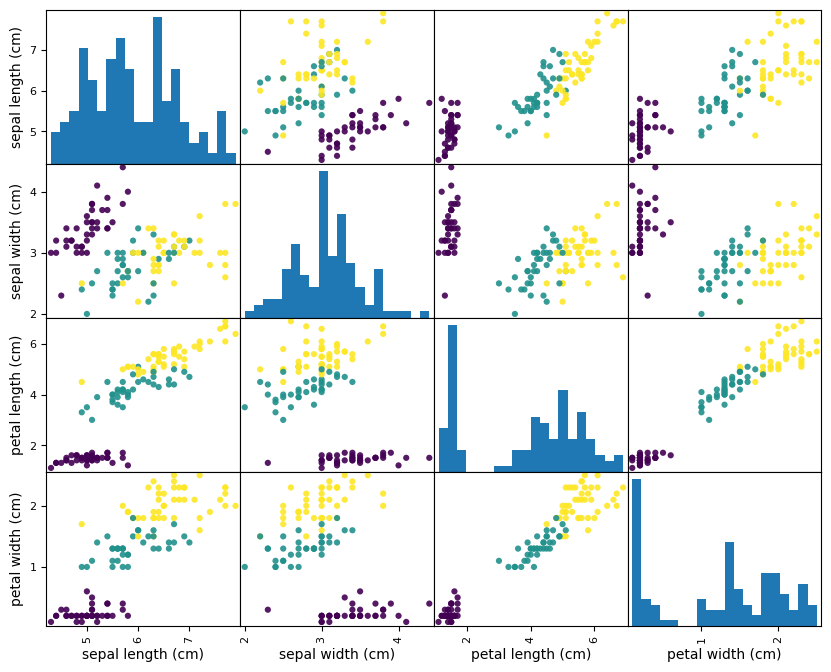

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
#绘制训练集的散点矩阵图
x_train_df = pd.DataFrame(x_train,columns=iris_data.feature_names)
pd.plotting.scatter_matrix(x_train_df,c = y_train,figsize=(10,8),hist_kwds={'bins':20},alpha= .9, s=80)
plt.show()

### 4构建模型

In [35]:
#支持向量机
from sklearn.svm import LinearSVC
#构造模型对象
class_model = LinearSVC(random_state=1,max_iter=10000) #最大的迭代次数
#从训练数据集中学习模型参数
class_model.fit(x_train,y_train)


LinearSVC(max_iter=10000, random_state=1)

### 5评估模型

In [4]:
y_train_predict = class_model.predict(x_train)
y_test_predict = class_model.predict(x_test)
print('测试集的预测分类:',y_test_predict)
print('测试集的真实分类:',y_test)

测试集的预测分类: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
测试集的真实分类: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


In [49]:
#计算准确率方法的1
import numpy as np
print('训练集的准确率:',np.mean(y_train_predict == y_train))
print('测试集的准确率:',np.mean(y_test_predict == y_test))

训练集的准确率: 0.9583333333333334
测试集的准确率: 1.0


In [50]:
#计算准确率方法2
print('训练集的准确率:',class_model.score(x_train,y_train))
print('测试集的准确率:',class_model.score(x_test,y_test))

训练集的准确率: 0.9583333333333334
测试集的准确率: 1.0


In [51]:
from sklearn import metrics
#打印混淆矩阵
print('混淆矩阵:\n',metrics.confusion_matrix(y_test,y_test_predict))
#打印分类性能报告
print('分类性能报告:\n',metrics.classification_report(y_test,y_test_predict))

混淆矩阵:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
分类性能报告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### 6做出预测

In [53]:
import numpy as np
x_new = np.array([[4.5,2.8,2.5,0.3]])
#调用模型
class_code = class_model.predict(x_new)
print('类型代码:\n',class_code)
print('类型名称:\n',iris_data['target_names'][class_code])


类型代码:
 [1]
类型名称:
 ['versicolor']


### 7模型保存

In [61]:
import joblib
joblib.dump(class_model,'./savedmodel/class_model.pkl')

['./savedmodel/class_model.pkl']

### 8模型的重新使用

In [64]:
import joblib
load_model = joblib.load('./savedmodel/class_model.pkl')
x_new = np.array([[5,3.3,2.3,0.6]])
#调用模型
class_code = class_model.predict(x_new)
print('类型代码:\n',class_code)
print('类型名称:\n',iris_data['target_names'][class_code])


类型代码:
 [0]
类型名称:
 ['setosa']


# 代码汇总

训练集特征与标签数据的形状: (120, 4) (120,)
测试集特征与标签数据形状: (30, 4) (30,)


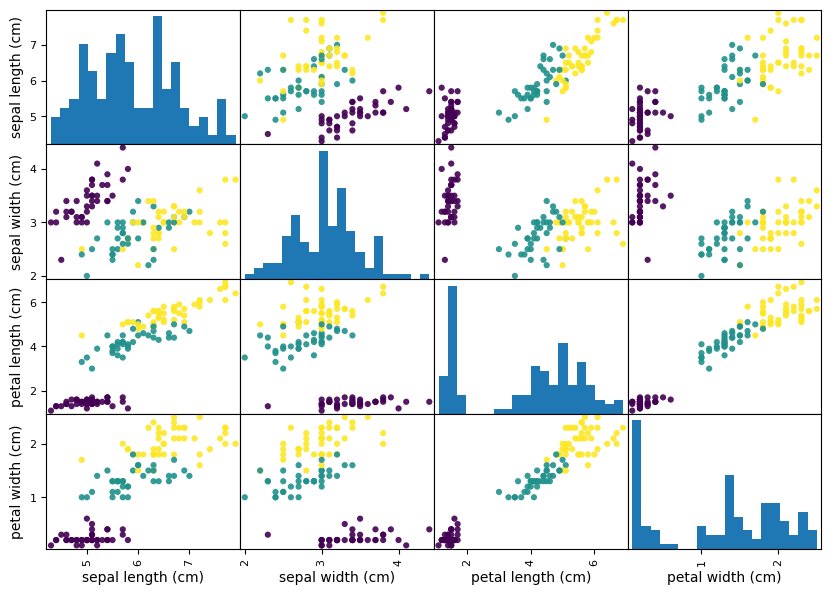

测试集的预测分类: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
测试集的真实分类: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
训练集的准确率: 0.9583333333333334
测试集的准确率: 1.0
混淆矩阵:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
分类性能报告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

类型代码:
 [1]
类型名称:
 ['versicolor']


In [5]:
# - * - coding:utf - 8 - * -
#example_鸢尾花分类.py
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from sklearn import metrics
import joblib
#1.导入数据
iris_data = load_iris()
#2.划分训练集和测试集
x_train,x_test,y_train,y_test = train_test_split(iris_data.data,iris_data.target,test_size=0.2,random_state=0)
print('训练集特征与标签数据的形状:',x_train.shape,y_train.shape)
print('测试集特征与标签数据形状:',x_test.shape,y_test.shape)
#3.绘制训练数据的散点图
iris_df = pd.DataFrame(x_train,columns=iris_data.feature_names)
pd.plotting.scatter_matrix(
    iris_df,               # 要可视化的DataFrame，包含需要分析的特征数据
    c=y_train,             # 为数据点指定颜色，这里使用训练集的标签(y_train)来区分不同类别
    figsize=(10,7),        # 指定图形的大小，宽10英寸，高7英寸
    hist_kwds={'bins':20}, # 传递给直方图的参数，这里设置直方图的分箱数为20
    alpha = .9,            # 数据点的透明度，值越接近1越不透明，0.9表示较高的不透明度
    s =80                  # 散点图中数据点的大小，80表示较大的点，便于观察
)
#构建模型对象
class_model = LinearSVC(random_state=1,max_iter=10000)
#从训练数据中学习模型参数
class_model.fit(x_train,y_train)
#5.评估模型
y_train_predict = class_model.predict(x_train)
y_test_predict = class_model.predict(x_test)
print('测试集的预测分类:',y_test_predict)
print('测试集的真实分类:',y_test)
#计算准确率方法2
print('训练集的准确率:',class_model.score(x_train,y_train))
print('测试集的准确率:',class_model.score(x_test,y_test))
#打印混淆矩阵
print('混淆矩阵:\n',metrics.confusion_matrix(y_test,y_test_predict))
#打印分类性能报告
print('分类性能报告:\n',metrics.classification_report(y_test,y_test_predict))
#6.对新数据进行预测
x_new = np.array([[4.5,2.8,2.5,0.3]])
#调用模型
class_code = class_model.predict(x_new)
print('类型代码:\n',class_code)
print('类型名称:\n',iris_data['target_names'][class_code])
#7.保存模型与调用
joblib.dump(class_model,'./savedmodel/class_model.pkl')
load_model = joblib.load('./savedmodel/class_model.pkl')